# Maximum Independent Set

The explicit Hamiltonian used for Maximum Independent Set (binary variables $x_i\in\{0,1\}$, $x_i=1$ means “select node i”) is : 

$H(\mathbf{x}) \;=\; A\sum_{(i,j)\in E} x_i x_j \;-\; B\sum_{i\in V} x_i$. 

1. $A\sum_{(i,j)\in E} x_i x_j$: penalty for selecting adjacent nodes (any edge with both endpoints selected adds energy). 
2. $-B\sum_i x_i$: reward for selecting more nodes (since we minimize H, this pushes size up). 
3. Choose $A \gg B$ to enforce independence strongly.

In the mean-field (what the FEM code optimizes), the expectation becomes:
$U(\mathbf{p}) \;=\; A\sum_{(i,j)\in E} p_i p_j \;-\; B\sum_i p_i$ (where U is the internal energy)
with the undirected double-counting handled via $a /2$ when using the symmetric adjacency matrix form.

Solved using sequential greedy algorithm. FEM learns a soft ranking over vertices; the final MIS is extracted by a sequential greedy pass using that ranking.

In [4]:
import torch
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

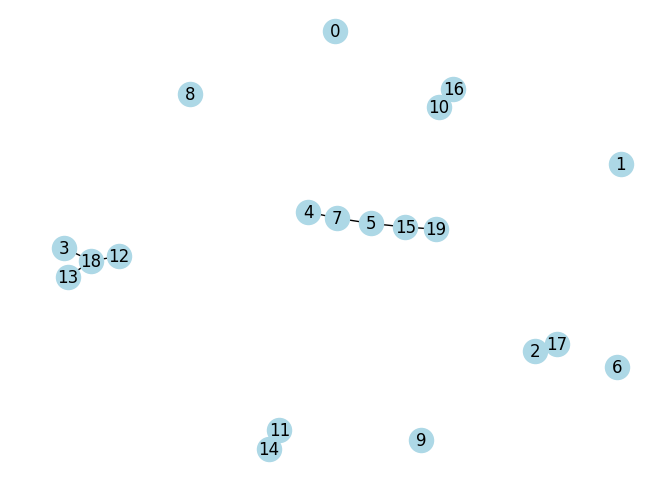

W shape: (20, 20)
Unique values in W: [0. 1.]


In [ ]:
# GRAPH UTILITIES
def random_binary_undirected_graph(n_nodes=15, edge_prob=0.07, seed=1, directed=False):
    return nx.erdos_renyi_graph(n=n_nodes, p=edge_prob, seed=seed, directed=directed)
def graph_to_binary_adjacency(G):
    n = G.number_of_nodes()
    W = np.zeros((n, n), dtype=np.float32)
    np.fill_diagonal(W, 0.0)
    for u, v in G.edges():
        W[u, v] = 1.0
        W[v, u] = 1.0
    return W
def draw_graph(G, seed=42):
    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos, with_labels=True, node_color="lightblue")
    plt.show()

# MIS plotting
def draw_graph_with_mis(G, x, seed=42):
    pos = nx.spring_layout(G, seed=seed)
    node_colors = ["tab:orange" if x[i] == 1 else "tab:blue" for i in G.nodes()]
    edge_colors = []
    for u, v in G.edges():
        edge_colors.append("red" if (x[u] == 1 and x[v] == 1) else "lightgray")
    nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors)
    plt.show()

# Example usage
G = random_binary_undirected_graph(n_nodes=20, edge_prob=0.07, seed=14)
draw_graph(G)
W = graph_to_binary_adjacency(G)
print("W shape:", W.shape)
print("Unique values in W:", np.unique(W))

In [32]:
def S_bernoulli(p, eps=1e-12):
    p = p.clamp(eps, 1 - eps)
    return -(p * p.log() + (1 - p) * (1 - p).log()).sum(1)
def mis_energy(W, p, A=10.0, B=1.0): 
    # As per hamiltonian definition
    return A * (((p @ W) * p).sum(1) / 2.0) - B * p.sum(1)

# Constraint repair heuristic and violation counting
def greedy_repair_mis_from_probs(G, p_vec):
    order = np.argsort(-p_vec)  # descending p
    blocked = set()
    x = np.zeros(len(p_vec), dtype=np.int32)

    for i in order:
        if i in blocked:
            continue
        x[i] = 1
        blocked.add(i)
        for nb in G.neighbors(i):
            blocked.add(nb)
    return x
def count_violations(W_np, x):
    x = x.astype(np.float32)
    return float(((x @ W_np) * x).sum() / 2.0)

In [35]:
def solve_mis(G, W_np_or_torch, batch=64, lr=0.05, steps=400, A=10.0, B=1.0, beta_min=0.5, beta_max=20.0):
    device = "mps" if torch.backends.mps.is_available() else "cpu"

    W = W_np_or_torch
    if not torch.is_tensor(W):
        W = torch.tensor(W, dtype=torch.float32)
    W = W.to(device)

    n = W.shape[0]
    h = torch.nn.Parameter(torch.zeros(batch, n, device=device))
    opt = torch.optim.Adam([h], lr=lr)
    beta_range = torch.linspace(beta_min, beta_max, steps=steps).to(device)

    for beta in beta_range:
        p = torch.sigmoid(h)
        Fval = mis_energy(W, p, A=A, B=B) - S_bernoulli(p) / beta
        opt.zero_grad()
        Fval.sum().backward()
        opt.step()

    p_all = torch.sigmoid(h).detach().cpu().numpy()   # (batch, n)
    h_all = h.detach().cpu().numpy()                  # (batch, n)

    best_x = None
    best_p = None
    best_h = None
    best_size = -1

    for r in range(batch):
        x_r = greedy_repair_mis_from_probs(G, p_all[r])
        size_r = int(x_r.sum())
        if size_r > best_size:
            best_size = size_r
            best_x = x_r
            best_p = p_all[r]
            best_h = h_all[r]

    return {
        "x_best": best_x,        # binary MIS solution
        "p_best": best_p,        # marginals (what sir asked for)
        "h_best": best_h,        # logits
        "best_size": best_size
    }

In [53]:
# Parameters
n_nodes   = 20
edge_prob = 0.07
seed      = 14
batch     = 64
steps     = 400
lr        = 0.05
beta_min  = 0.5
beta_max  = 20.0
A         = 10.0
B         = 1.0

G = random_binary_undirected_graph(n_nodes=n_nodes, edge_prob=edge_prob, seed=seed)
W = graph_to_binary_adjacency(G)

out = solve_mis(G, W, batch=batch, lr=lr, steps=steps, beta_min=beta_min, beta_max=beta_max, A=A, B=B)
best_size, h_best, p_best, x_best = out["best_size"], out["h_best"], out["p_best"], out["x_best"]

print("Best MIS size:", best_size)
print("Best logits:", h_best)
print("Best marginals:", p_best)
print("Best x:", x_best)

Best MIS size: 14
Best logits: [ 5.429216   5.429216  -2.0796924  3.8472085  3.759257   1.7705575
  5.429216  -5.8380623  5.429216   5.429216  -2.0796924 -2.0796924
  3.8472085  3.8472085 -2.0796924 -5.8380623 -2.0796924 -2.0796924
 -6.1996307  3.759257 ]
Best marginals: [0.9956326  0.9956326  0.11108633 0.97910666 0.9772296  0.854527
 0.9956326  0.00290601 0.9956326  0.9956326  0.11108633 0.11108633
 0.97910666 0.97910666 0.11108633 0.00290601 0.11108633 0.11108633
 0.00202607 0.9772296 ]
Best x: [1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 1]


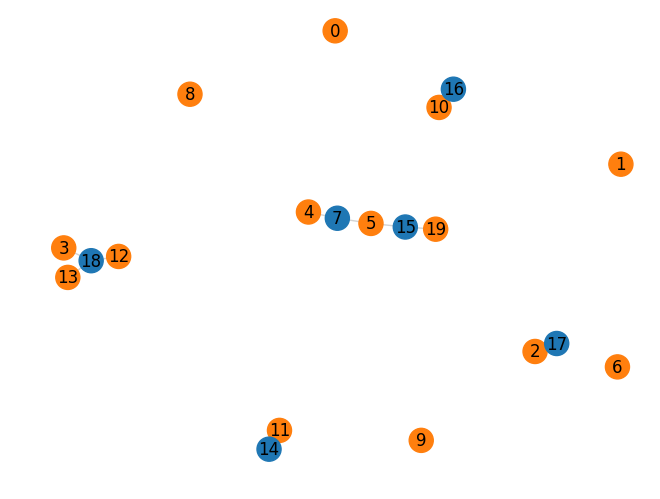

,logit,marginal_p(x=1),independent_set_member
0,5.429216,0.995633,Independent
1,5.429216,0.995633,Independent
2,-2.079692,0.111086,Independent
3,3.847208,0.979107,Independent
4,3.759257,0.977230,Independent
5,1.770558,0.854527,Independent
6,5.429216,0.995633,Independent
7,-5.838062,0.002906,Not Independent
8,5.429216,0.995633,Independent
9,5.429216,0.995633,Independent


In [55]:
import pandas as pd
def mis_marginals_dataframe(h_best, p_best):
    n = len(h_best)
    df = pd.DataFrame({
        "logit": h_best,
        "marginal_p(x=1)": p_best,
        "independent_set_member": ["Independent" if x == 1 else "Not Independent" for x in x_best]
    })
    return df

df_mis = mis_marginals_dataframe(h_best, p_best)
draw_graph_with_mis(G, x_best)
df_mis